## Reasoning Patch

In [1]:
%load_ext autoreload
%autoreload 2

### Overview

### Set-up

In [2]:
import torch
from tensordict import TensorDict
import gc
import pandas as pd
from tqdm import tqdm

import sys
sys.path.append("src")
import _util
import _mapping
import _prompt
from _intervention import prepare_batch_multitoken_intervention, batch_intervene, forward_with_cache, prepare_batch_multitoken_steering

In [3]:
model_type = "GPT-OSS_stepwise" # GPT-OSS or R1
prompt_type = "h_pre_penultimate_sum" # {null / h / h1 / h2}_{null / pre_result / pre_final_sum / ...}
intervention_loc = "" # restatement or reasoning or restatement_and_reasoning
intervention_ids = [20]
tok_pos_fn = _mapping.intervene_id_to_tok_pos_stepwise_3_digit_h
result_dir = "intervention_effect_tensors"

# Steering Config———————————————————————————————————————
batch_size = 24
device = "cuda"

In [4]:
num_layers = 24
hidden_size = 2880
if "GPT-OSS" in model_type:
    model, tokenizer = _util.load_OSS()
    num_layers = model.config.num_hidden_layers
    hidden_size = model.config.hidden_size
elif "R1" in model_type:
    model, tokenizer = _util.load_R1()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [5]:
if prompt_type:
    prompt_type = "_" + prompt_type

# Load the divided prompts dataset
if 'h1' in prompt_type:
    prompts = pd.read_csv(f"data/{model_type}/h1_prompts{prompt_type[3:]}.csv")
elif 'h' in prompt_type:
    prompts = pd.read_csv(f"data/{model_type}/h_prompts{prompt_type[2:]}.csv")
else:
    prompts = pd.read_csv(f"data/{model_type}/prompts{prompt_type}.csv")

# prompts = pd.read_csv("experiments/steering/output/GPT-OSS_stepwise/steering_dataset/filtered_steering_dataset.csv")
prompts["base_sum"] = prompts["base_sum"].astype('Int64')
prompts["source_sum"] = prompts["source_sum"].astype('Int64')
print(f"loaded {len(prompts)} prompts")

loaded 256 prompts


In [6]:
if intervention_ids == None:
    if 'h' in prompt_type:
        if model_type == "GPT-OSS_stepwise":
            intervention_ids_dict = _mapping.intervene_ids_stepwise_3_digit_h
        elif model_type == "GPT-OSS_vanilla":
            intervention_ids_dict = _mapping.intervene_ids_vanilla_2_digit_h
        elif model_type == "R1":
            intervention_ids_dict = _mapping.intervene_ids_R1_3_digit_h
        else:
            raise ValueError(f"Invalid model type: {model_type}")
    else:
        if model_type == "GPT-OSS_stepwise":
            intervention_ids_dict = _mapping.intervene_ids_stepwise_3_digit
        elif model_type == "R1":
            intervention_ids_dict = _mapping.intervene_ids_R1_3_digit
        else:
            raise ValueError(f"Invalid model type: {model_type}")

    if intervention_loc == "restatement":
        intervention_ids = intervention_ids_dict["restatement"]
    elif intervention_loc == "reasoning":
        intervention_ids = intervention_ids_dict["reasoning"]
    elif intervention_loc == "restatement_and_reasoning":
        intervention_ids = intervention_ids_dict["restatement"] + intervention_ids_dict["reasoning"]
    else:
        raise ValueError(f"Invalid intervention location: {intervention_loc}")

print(intervention_ids)

[20]


In [7]:
tok_pos_list = [tok_pos_fn[id] for id in intervention_ids]
print(tok_pos_list)

[235]


## Get Mean Activation

In [8]:
natural_activation_sum = TensorDict({str(layer): torch.zeros(hidden_size).to(device) for layer in range(num_layers)})
intervened_activation_sum = TensorDict({str(layer): torch.zeros(hidden_size).to(device) for layer in range(num_layers)})
mean_natural_activation = TensorDict({str(layer): torch.zeros(hidden_size).to(device) for layer in range(num_layers)})
mean_intervened_activation = TensorDict({str(layer): torch.zeros(hidden_size).to(device) for layer in range(num_layers)})
intervention_effect = TensorDict({str(layer): torch.zeros(hidden_size).to(device) for layer in range(num_layers)})

for i in tqdm(range(0, len(prompts), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = prompts.iloc[i:i+batch_size]

    tokens = tokenizer(batch_rows['base_prompt'].tolist(), add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, cache = forward_with_cache(model, tokens["input_ids"], attention_mask=tokens["attention_mask"])
    for layer in range(num_layers):
        activations = cache[f"model.layers.{layer}"][:,tok_pos_list,:].to(device)
        natural_activation_sum[str(layer)] = natural_activation_sum[str(layer)] + activations.sum(dim=0).sum(dim=0)
    
    intervention_prompts = [_prompt.get_intervened_prompt(intervention_ids, row['base_prompt'], row['source_prompt']) for _, row in batch_rows.iterrows()]
    intervened_tokens = tokenizer(intervention_prompts, add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, intervened_cache = forward_with_cache(model, intervened_tokens["input_ids"], attention_mask=intervened_tokens["attention_mask"])
    for layer in range(num_layers):
        intervened_activations = intervened_cache[f"model.layers.{layer}"][:,tok_pos_list,:].to(device)
        intervened_activation_sum[str(layer)] = intervened_activation_sum[str(layer)] + intervened_activations.sum(dim=0).sum(dim=0)

    del tokens, intervened_tokens, cache, intervened_cache
    torch.cuda.empty_cache()
    gc.collect()

for layer in range(num_layers):
    mean_natural_activation[str(layer)] = natural_activation_sum[str(layer)] / len(prompts)
    mean_intervened_activation[str(layer)] = intervened_activation_sum[str(layer)] / len(prompts)
    intervention_effect[str(layer)] = mean_intervened_activation[str(layer)] - mean_natural_activation[str(layer)]


  0%|                                                                                      | 0/11 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████| 11/11 [01:38<00:00,  8.96s/it]


In [10]:
tensor_directory = f"experiments/steering/output/GPT-OSS_stepwise/intervention_effect_tensors/{prompt_type[1:]}{intervention_loc}/"
import os
os.makedirs(tensor_directory, exist_ok=True)

torch.save(mean_natural_activation, tensor_directory + "mean_natural_activation.pt")
torch.save(mean_intervened_activation, tensor_directory + "mean_intervened_activation.pt")
torch.save(intervention_effect, tensor_directory + "intervention_effect.pt")

# IGNORE EVERYTHING BELOW

In [ ]:
steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
steering_vector = steering_vectors["backtracking"]["mean"][activation_layer].to(device)
print(torch.nn.functional.cosine_similarity(steering_vector, mean_intervened_activation - mean_natural_activation, dim=0))
print(torch.nn.functional.cosine_similarity(steering_vector, mean_natural_activation, dim=0))
print(torch.nn.functional.cosine_similarity(steering_vector, mean_intervened_activation, dim=0))

scalar_projection = torch.dot(mean_intervened_activation - mean_natural_activation, steering_vector) / torch.norm(steering_vector)
print(scalar_projection)
print(scalar_projection / torch.norm(steering_vector))
print(torch.norm(steering_vector))
print(torch.norm(mean_intervened_activation - mean_natural_activation))
print(torch.norm(mean_intervened_activation))
print(torch.norm(mean_natural_activation))

tensor(0.0171, device='cuda:4')
tensor(0.7848, device='cuda:4')
tensor(0.7835, device='cuda:4')
tensor(35.1703, device='cuda:4')
tensor(0.0114, device='cuda:4')
tensor(3078.5500, device='cuda:4')
tensor(2059.7134, device='cuda:4')
tensor(3181.5759, device='cuda:4')
tensor(3131.3401, device='cuda:4')


In [ ]:
activation_layer = 16
device = "cuda:4"

steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
steering_vector = steering_vectors["backtracking"]["mean"][activation_layer].to(device).to(torch.bfloat16)
mean_diff_vector = torch.load("experiments/activation_intervention/intervention_effect_gpt-oss-20b.pt").to(device).to(torch.bfloat16)

def get_scalar_projection(vector_1, vector_2):
    return torch.dot(vector_1, vector_2) / torch.norm(vector_2)

In [ ]:
batch_size = 24

backtrack_cosine_similarities = []
backtrack_scalar_projection_ratios = []
mean_diff_cosine_similarities = []
mean_diff_scalar_projection_ratios = []
for i in tqdm(range(0, len(prompts), batch_size)):
    torch.cuda.empty_cache()
    gc.collect()
    batch_rows = prompts.iloc[i:i+batch_size]

    tokens = tokenizer(batch_rows['base_prompt'].tolist(), add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, cache = forward_with_cache(model, tokens["input_ids"], attention_mask=tokens["attention_mask"])
    activations = cache[f"model.layers.{activation_layer}"][:,tok_pos_list,:]
    
    intervention_prompts = [_prompt.get_intervened_prompt(intervention_ids, row['base_prompt'], row['source_prompt']) for _, row in batch_rows.iterrows()]
    intervened_tokens = tokenizer(intervention_prompts, add_special_tokens=False, return_tensors="pt", padding=True, padding_side="left").to(model.device)

    _, intervened_cache = forward_with_cache(model, intervened_tokens["input_ids"], attention_mask=intervened_tokens["attention_mask"])
    intervened_activations = intervened_cache[f"model.layers.{activation_layer}"][:,tok_pos_list,:]

    for intervened_activation, activation in zip(intervened_activations, activations):
        diff = intervened_activation[0] - activation[0]
        backtrack_cosine_similarities.append(torch.nn.functional.cosine_similarity(diff, steering_vector, dim=0))
        backtrack_scalar_projection_ratios.append(get_scalar_projection(diff, steering_vector) / torch.norm(steering_vector))
        mean_diff_cosine_similarities.append(torch.nn.functional.cosine_similarity(diff, mean_diff_vector, dim=0))
        mean_diff_scalar_projection_ratios.append(get_scalar_projection(diff, mean_diff_vector) / torch.norm(mean_diff_vector))

    del tokens, intervened_tokens, cache, intervened_cache
    torch.cuda.empty_cache()
    gc.collect()
   


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [01:53<00:00, 10.29s/it]


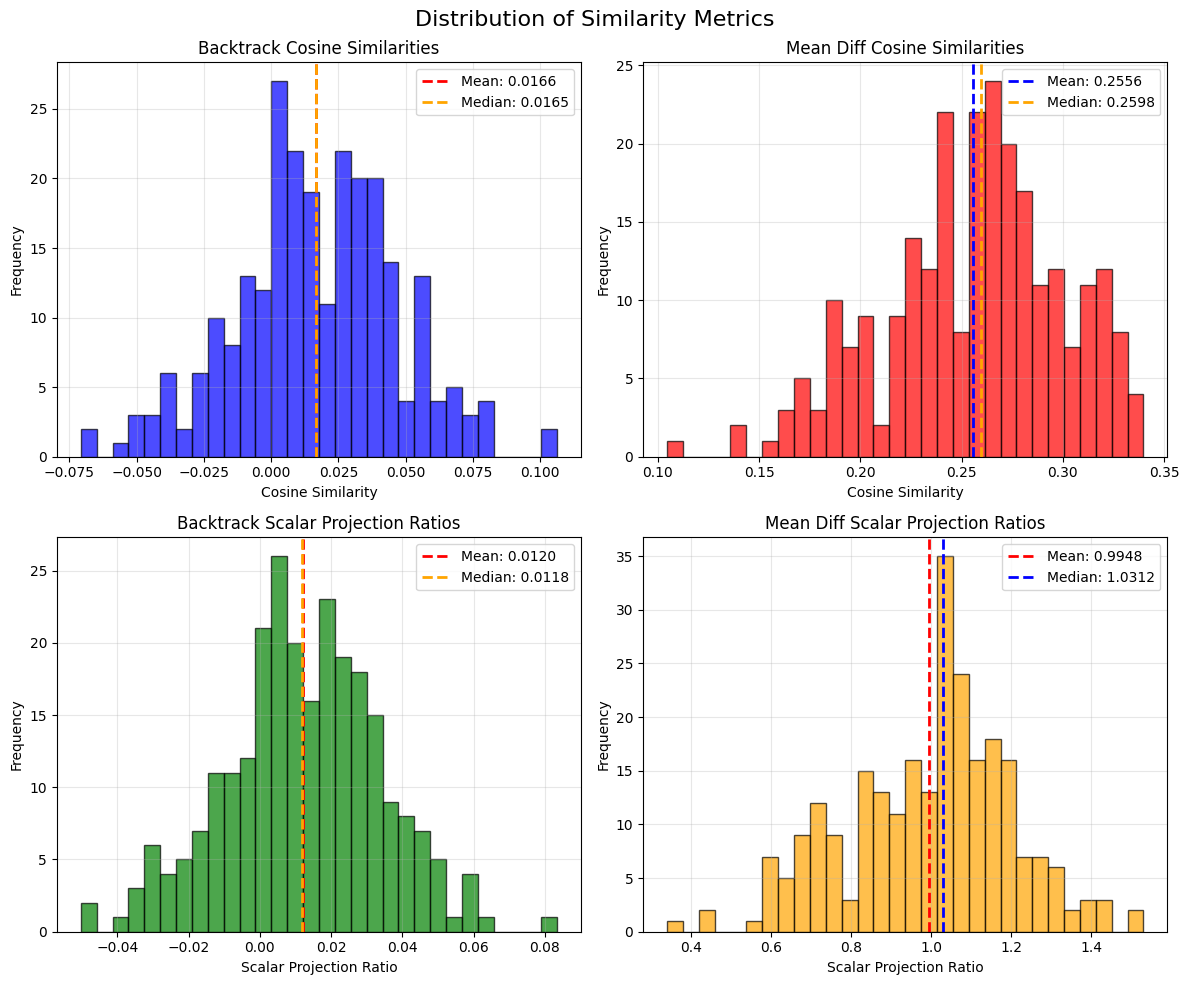

Summary Statistics:
Backtrack Cosine Similarities - Mean: 0.0166, Median: 0.0165, Std: 0.0302
Mean Diff Cosine Similarities - Mean: 0.2556, Median: 0.2598, Std: 0.0440
Backtrack Scalar Projection Ratios - Mean: 0.0120, Median: 0.0118, Std: 0.0217
Mean Diff Scalar Projection Ratios - Mean: 0.9948, Median: 1.0312, Std: 0.2082


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Convert tensors to numpy arrays for plotting
backtrack_cosine_similarities_np = [sim.cpu().to(torch.float32).numpy() for sim in backtrack_cosine_similarities]
mean_diff_cosine_similarities_np = [sim.cpu().to(torch.float32).numpy() for sim in mean_diff_cosine_similarities]
backtrack_scalar_projection_ratios_np = [ratio.cpu().to(torch.float32).numpy() for ratio in backtrack_scalar_projection_ratios]
mean_diff_scalar_projection_ratios_np = [ratio.cpu().to(torch.float32).numpy() for ratio in mean_diff_scalar_projection_ratios]

# Calculate statistics
backtrack_cos_mean = np.mean(backtrack_cosine_similarities_np)
backtrack_cos_median = np.median(backtrack_cosine_similarities_np)
mean_diff_cos_mean = np.mean(mean_diff_cosine_similarities_np)
mean_diff_cos_median = np.median(mean_diff_cosine_similarities_np)
backtrack_proj_mean = np.mean(backtrack_scalar_projection_ratios_np)
backtrack_proj_median = np.median(backtrack_scalar_projection_ratios_np)
mean_diff_proj_mean = np.mean(mean_diff_scalar_projection_ratios_np)
mean_diff_proj_median = np.median(mean_diff_scalar_projection_ratios_np)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Similarity Metrics', fontsize=16)

# Plot backtrack cosine similarities
axes[0, 0].hist(backtrack_cosine_similarities_np, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(backtrack_cos_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {backtrack_cos_mean:.4f}')
axes[0, 0].axvline(backtrack_cos_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {backtrack_cos_median:.4f}')
axes[0, 0].set_title('Backtrack Cosine Similarities')
axes[0, 0].set_xlabel('Cosine Similarity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot mean diff cosine similarities
axes[0, 1].hist(mean_diff_cosine_similarities_np, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[0, 1].axvline(mean_diff_cos_mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_diff_cos_mean:.4f}')
axes[0, 1].axvline(mean_diff_cos_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {mean_diff_cos_median:.4f}')
axes[0, 1].set_title('Mean Diff Cosine Similarities')
axes[0, 1].set_xlabel('Cosine Similarity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot backtrack scalar projection ratios
axes[1, 0].hist(backtrack_scalar_projection_ratios_np, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].axvline(backtrack_proj_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {backtrack_proj_mean:.4f}')
axes[1, 0].axvline(backtrack_proj_median, color='orange', linestyle='--', linewidth=2, label=f'Median: {backtrack_proj_median:.4f}')
axes[1, 0].set_title('Backtrack Scalar Projection Ratios')
axes[1, 0].set_xlabel('Scalar Projection Ratio')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot mean diff scalar projection ratios
axes[1, 1].hist(mean_diff_scalar_projection_ratios_np, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].axvline(mean_diff_proj_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_diff_proj_mean:.4f}')
axes[1, 1].axvline(mean_diff_proj_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {mean_diff_proj_median:.4f}')
axes[1, 1].set_title('Mean Diff Scalar Projection Ratios')
axes[1, 1].set_xlabel('Scalar Projection Ratio')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(f"Backtrack Cosine Similarities - Mean: {backtrack_cos_mean:.4f}, Median: {backtrack_cos_median:.4f}, Std: {np.std(backtrack_cosine_similarities_np):.4f}")
print(f"Mean Diff Cosine Similarities - Mean: {mean_diff_cos_mean:.4f}, Median: {mean_diff_cos_median:.4f}, Std: {np.std(mean_diff_cosine_similarities_np):.4f}")
print(f"Backtrack Scalar Projection Ratios - Mean: {backtrack_proj_mean:.4f}, Median: {backtrack_proj_median:.4f}, Std: {np.std(backtrack_scalar_projection_ratios_np):.4f}")
print(f"Mean Diff Scalar Projection Ratios - Mean: {mean_diff_proj_mean:.4f}, Median: {mean_diff_proj_median:.4f}, Std: {np.std(mean_diff_scalar_projection_ratios_np):.4f}")
